In [2]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle, Ring

# L3 Cavity with Oxidized Holes — 3-hole optimized
Optimized L3 cavity (GaAs, 3 nearest-neighbor end-hole shifts from autograd optimization) with
thin oxide rings on hole sidewalls. Sweeps oxide thickness to study effect on Q.

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


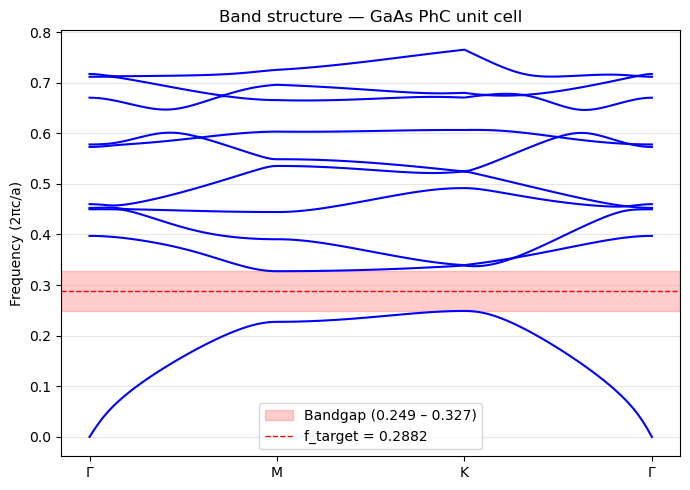

In [3]:
# ── Band structure of the perfect PhC (unit cell) ────────────────────────────────────────

# ── Physical parameters ───────────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── Supercell parameters ─────────────────────────────────────────────────────────
Nx, Ny = 16, 10

# Oxide material
n_oxide = 1.72
eps_oxide = n_oxide**2

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized 3-hole shifts (from autograd optimization notebook)
# ic=0 \u2192 xp=2.0 (1st neighbor), ic=1 \u2192 xp=3.0 (2nd), ic=2 \u2192 xp=4.0 (3rd)
dx_opt_3h = [0.27239, 0.21982, 0.0]
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt_3h[0]
dx[1] = dx_opt_3h[1]
dx[2] = dx_opt_3h[2]

print(f'nc = {nc} holes per quadrant')
print(f'Optimized 3-hole shifts:')
for i, s in enumerate(dx_opt_3h):
    print(f'  dx[{i}] = {s:.5f}a = {s * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized 3-hole shifts:
  dx[0] = 0.27239a = 68.1 nm
  dx[1] = 0.21982a = 55.0 nm
  dx[2] = 0.00000a = 0.0 nm


In [5]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep results to a timestamped folder in data/.

    Parameters
    ----------
    name : str
        Short sweep name (used in folder name).
    arrays_dict : dict
        {label: np.array} \u2014 each array is saved as a .npy file.
    **extra_params :
        Sweep-specific parameters to log in info.txt.
    """
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    # Save arrays
    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    # Write info.txt
    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')

        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'dslab = {dslab:.4f} ({dslab * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n')
        f.write(f'n_oxide = {n_oxide}\n')
        f.write(f'eps_oxide = {eps_oxide:.4f}\n\n')

        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'nc = {nc}\n')
        f.write(f'dx_opt_3h = {dx_opt_3h}\n')
        for i, s in enumerate(dx_opt_3h):
            f.write(f'  dx[{i}] = {s:.5f}a ({s * a_nm:.1f} nm)\n')
        f.write('\n')

        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = 10\n')
        f.write(f'gmode_inds = [0]\n\n')

        f.write('--- Bandgap ---\n')
        f.write(f'f_lb = {f_lb:.6f}\n')
        f.write(f'f_ub = {f_ub:.6f}\n')
        f.write(f'f_target = {f_target:.6f}\n')
        f.write(f'f_base = {f_base:.6f}\n')
        f.write(f'Q_base = {Q_base:.1f}\n\n')

        f.write('--- Sweep-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')

        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

In [6]:
def cavity_oxidized_3h(t_ox_nm, consume_ratio=0.5, r_nm=None, dx_shifts=None):
    """Build an L3 cavity with oxide on ALL exposed surfaces (3-hole optimized).

    Oxide grows both into the GaAs (consuming it) and outward (adding volume).
    The consume_ratio controls the split, applied to both top/bottom surfaces
    and hole sidewalls.

    Parameters
    ----------
    t_ox_nm : float
        Total oxide thickness in nm. Set to 0 for unoxidized cavity.
    consume_ratio : float, optional
        Fraction of oxide that replaces GaAs (0 to 1). Default 0.5.
        0 = all oxide added as extra volume (no GaAs consumed).
        1 = all oxide replaces GaAs (no extra volume added).
    r_nm : float or None, optional
        Hole radius in nm. If None, uses the global `ra` (75 nm default).
    dx_shifts : list of 3 floats or None, optional
        End-hole shifts in units of a for the 3 nearest neighbors.
        If None, uses the global `dx_opt_3h`.
    """
    t_ox = t_ox_nm / a_nm  # nm \u2192 normalized units
    r_a = (r_nm / a_nm) if r_nm is not None else ra

    dx_local = dx.copy()
    if dx_shifts is not None:
        dx_local[0] = dx_shifts[0]
        dx_local[1] = dx_shifts[1]
        dx_local[2] = dx_shifts[2]

    if t_ox_nm > 0:
        d_consume = consume_ratio * t_ox
        d_slab_eff = dslab - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_nm} nm '
                f'>= dslab = {dslab * a_nm} nm')
        r_outer = r_a + consume_ratio * t_ox
        r_inner = r_a - (1 - consume_ratio) * t_ox
    else:
        d_slab_eff = dslab

    phc = legume.PhotCryst(lattice)

    if t_ox_nm > 0:
        # Layer 0: bottom oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
        # Layer 1: thinned GaAs slab
        phc.add_layer(d=d_slab_eff, eps_b=n_slab**2)
        # Layer 2: top oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
    else:
        # No oxide: single slab layer (layer 0)
        phc.add_layer(d=dslab, eps_b=n_slab**2)

    slab_idx = 1 if t_ox_nm > 0 else 0

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx_local[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_nm > 0:
                # Slab layer: oxide ring (consumes GaAs + grows into air)
                phc.add_shape(Ring(eps=eps_oxide, r_i=r_inner, r_o=r_outer,
                                  x_cent=px, y_cent=py), layer=slab_idx)
                phc.add_shape(Circle(eps=1.0, r=r_inner,
                                    x_cent=px, y_cent=py), layer=slab_idx)
                # Oxide layers: air holes punch through
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=0)
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=2)
            else:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_a))

    return phc

## Visualize structure

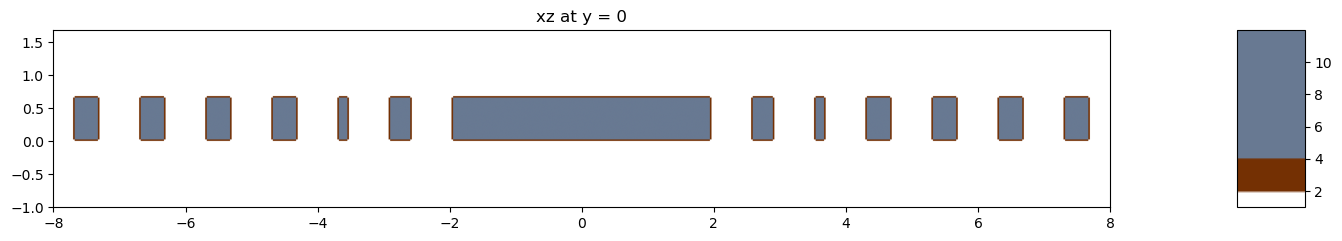

In [7]:
# Visualize the oxidized cavity (t_ox = 5 nm)
phc_viz = cavity_oxidized_3h(6, consume_ratio=1.0)
gme_viz = legume.GuidedModeExp(phc_viz, gmax=2, truncate_g='tbt')

# Discrete colormap: air=white, oxide=gold, GaAs=dark blue
# eps values: air=1.0, oxide~2.96, GaAs~11.97
# Normalized positions in [min_eps, max_eps] = [1, 12]: oxide at ~0.18
import matplotlib.colors as mcolors
cmap_discrete = mcolors.LinearSegmentedColormap.from_list('discrete_eps', [
    (0.00, 'white'),     # air
    (0.08, 'white'),
    (0.09, "#743003"),   # oxide
    (0.27, '#743003'),
    (0.28, "#687992"),   # GaAs
    (1.00, '#687992')
])

legume.viz.structure(phc_viz, xz=True, yz=False, xy=False, figsize=14, cmap=cmap_discrete,
                     Nx=2000, Ny=1000, Nz=600)

## Baseline: unoxidized L3 cavity (3-hole optimized)

16.048s total time for real part of frequencies in GuidedModeExp, of which
  0.118s (1%) for guided modes computation using the gmode_compute='exact' method
  0.403s (3%) for inverse matrix of Fourier-space permittivity
  13.729s (86%) for matrix diagionalization using the 'eigh' solver
  1.797s (11%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25691,  Q = 1438926.2 <-- IN BANDGAP
  Mode 1: f = 0.26561,  Q = 4613.7 <-- IN BANDGAP
  Mode 2: f = 0.27941,  Q = 843.1 <-- IN BANDGAP
  Mode 3: f = 0.28151,  Q = 245.9 <-- IN BANDGAP
  Mode 4: f = 0.28364,  Q = 276.6 <-- IN BANDGAP
  Mode 5: f = 0.28506,  Q = 2040.6 <-- IN BANDGAP
  Mode 6: f = 0.30886,  Q = 3105.4 <-- IN BANDGAP
  Mode 7: f = 0.30928,  Q = 2000.2 <-- IN BANDGAP
  Mode 8: f = 0.30982,  Q = 1908.5 <-- IN BANDGAP
  Mode 9: f = 0.32197,  Q = 3497.9 <

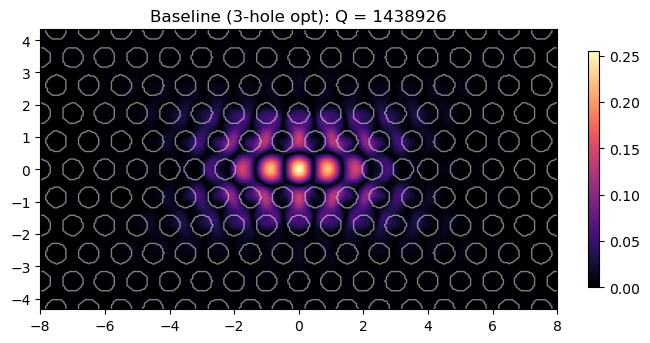

In [8]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx', 'compute_im': False}

# Unoxidized cavity
phc_base = cavity_oxidized_3h(0)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify the L3 cavity mode (first mode in bandgap)
print(f'\nModes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (no oxide, 3-hole opt): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline (3-hole opt): Q = {Q_base:.0f}')
plt.show()

## Single oxidized run

14.716s total time for real part of frequencies in GuidedModeExp, of which
  0.233s (2%) for guided modes computation using the gmode_compute='exact' method
  1.559s (11%) for inverse matrix of Fourier-space permittivity
  9.891s (67%) for matrix diagionalization using the 'eigh' solver
  3.031s (21%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
t_ox = 4.5 nm:  f = 0.25896,  Q = 1016.9
Change from baseline:  Δf = 0.00205,  ΔQ = -1437909.3


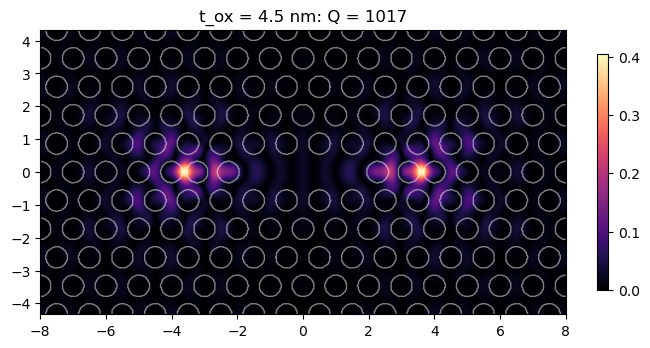

In [9]:
# Single oxidized run (t_ox = 4.5 nm)
t_ox_test = 4.5  # nm

phc_ox = cavity_oxidized_3h(t_ox_test, r_nm=75, consume_ratio=1.0)
gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
gme_ox.run(kpoints=np.array([[0], [0]]), **options)

# Find cavity mode: candidates near f_base, pick highest Q
all_freqs_ox = gme_ox.freqs[0, :]
candidates = np.where(np.abs(all_freqs_ox - f_base) < 0.005)[0]
best_Q_ox, mind_ox = -1, 0
for c in candidates:
    (fim, _, _) = gme_ox.compute_rad(0, [c])
    Qc = gme_ox.freqs[0, c] / (2 * fim[0])
    if Qc > best_Q_ox:
        best_Q_ox, mind_ox = Qc, c

Q_ox = best_Q_ox
f_ox = gme_ox.freqs[0, mind_ox]

print(f't_ox = {t_ox_test} nm:  f = {f_ox:.5f},  Q = {Q_ox:.1f}')
print(f'Change from baseline:  \u0394f = {f_ox - f_base:.5f},  \u0394Q = {Q_ox - Q_base:.1f}')

ax = legume.viz.field(gme_ox, 'e', 0, mind_ox, z=dslab/2,
                      component='y', val='abs', N1=500, N2=400)
plt.title(f't_ox = {t_ox_test} nm: Q = {Q_ox:.0f}')
plt.show()

## Q factor vs oxide thickness

In [10]:
# Sweep oxide thickness (consume_ratio = 0.5)
t_ox_values = np.linspace(0, 10, 4)  # nm
Qs_full = []
freqs_full = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking with baseline L3 frequency

print('Sweeping oxide thickness (consume_ratio = 0.5):')
for t_ox_nm in t_ox_values:
    phc_s = cavity_oxidized_3h(t_ox_nm)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Q-based mode selection: find candidates near f_prev, pick highest Q
    all_freqs = gme_s.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s

    Qs_full.append(best_Q)
    freqs_full.append(f_s)
    print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

if SAVE_DATA:
    save_sweep('3h_oxide_thickness', {
        't_ox_nm': t_ox_values,
        'Qs': np.array(Qs_full),
        'freqs': np.array(freqs_full),
    }, consume_ratio=0.5, r_nm=75)

Sweeping oxide thickness (consume_ratio = 0.5):
  t_ox =  0.00 nm,  Q =  1438926.2,  f = 0.25691  (mode 8)
  t_ox =  3.33 nm,  Q =  1085146.0,  f = 0.25847  (mode 8)
  t_ox =  6.67 nm,  Q =   662929.6,  f = 0.26013  (mode 8)
  t_ox = 10.00 nm,  Q =   369647.2,  f = 0.26189  (mode 8)
Sweep complete.
Results saved to data/2026-03-20_165015_3h_oxide_thickness/


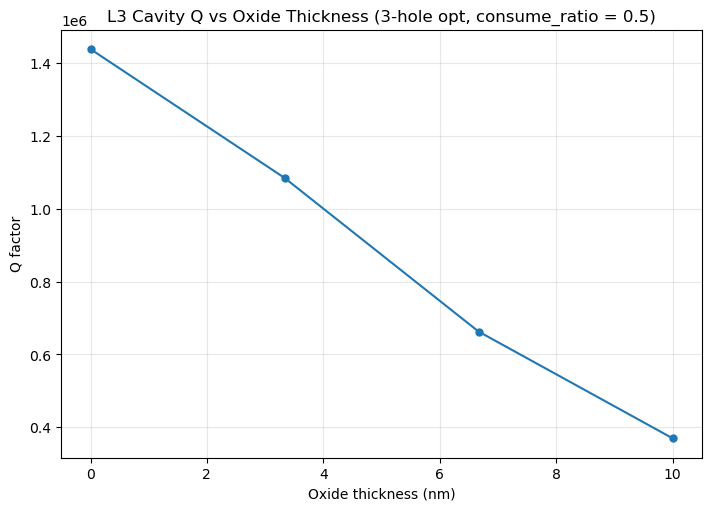

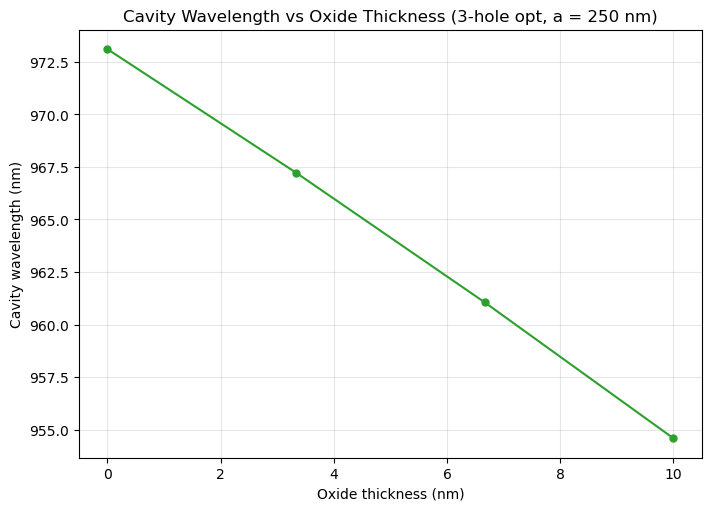

 t_ox (nm)           Q    f (norm)      λ (nm)
-----------------------------------------------------------------
      0.00   1438926.2     0.25691       973.1
      3.33   1085146.0     0.25847       967.2
      6.67    662929.6     0.26013       961.1
     10.00    369647.2     0.26189       954.6


In [11]:
# ── Plot full-oxidation sweep results ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax1.plot(t_ox_values, Qs_full, 'o-', lw=1.5, markersize=5)
ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Oxide Thickness (3-hole opt, consume_ratio = 0.5)')
ax1.grid(True, alpha=0.3)
plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────────
lambdas_full_nm = [a_nm / f for f in freqs_full]

fig, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax2.plot(t_ox_values, lambdas_full_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Oxide Thickness (3-hole opt, a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"t_ox (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"\u03bb (nm)":>10}')
print('-' * 65)
for t, q, f, lam in zip(t_ox_values, Qs_full, freqs_full, lambdas_full_nm):
    print(f'{t:>10.2f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

## Combined sweep: Q vs oxide thickness for different hole radii

In [12]:
# Combined sweep: oxide thickness for each hole radius
r_nm_list = [73, 74, 75, 76, 77]  # nm
t_ox_vals = np.linspace(0, 10, 21)  # nm
results = {}  # {r_nm: {'Qs': [...], 'freqs': [...]}}

options_sweep2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for r_nm in r_nm_list:
    Qs, freqs = [], []
    f_prev = f_base  # re-seed for each radius

    print(f'\n--- r = {r_nm} nm ---')
    for t_ox_nm in t_ox_vals:
        phc_s = cavity_oxidized_3h(t_ox_nm, r_nm=r_nm)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep2)

        # Q-based mode selection: find candidates near f_prev, pick highest Q
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results[r_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nCombined sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals, 'r_nm_list': np.array(r_nm_list)}
    for r_nm in r_nm_list:
        arrays[f'Qs_r{r_nm}'] = np.array(results[r_nm]['Qs'])
        arrays[f'freqs_r{r_nm}'] = np.array(results[r_nm]['freqs'])
    save_sweep('3h_radius_oxide', arrays, consume_ratio=0.5, r_nm_list=r_nm_list)


--- r = 73 nm ---
  t_ox =  0.00 nm,  Q =  1143205.2,  f = 0.25521  (mode 8)
  t_ox =  0.50 nm,  Q =  1184737.3,  f = 0.25544  (mode 8)
  t_ox =  1.00 nm,  Q =  1225579.4,  f = 0.25566  (mode 8)
  t_ox =  1.50 nm,  Q =  1264900.5,  f = 0.25589  (mode 8)
  t_ox =  2.00 nm,  Q =  1301721.1,  f = 0.25612  (mode 8)
  t_ox =  2.50 nm,  Q =  1334928.4,  f = 0.25635  (mode 8)
  t_ox =  3.00 nm,  Q =  1363310.9,  f = 0.25658  (mode 8)
  t_ox =  3.50 nm,  Q =  1385613.1,  f = 0.25682  (mode 8)
  t_ox =  4.00 nm,  Q =  1400613.0,  f = 0.25705  (mode 8)
  t_ox =  4.50 nm,  Q =  1407216.0,  f = 0.25729  (mode 8)
  t_ox =  5.00 nm,  Q =  1404557.3,  f = 0.25753  (mode 8)
  t_ox =  5.50 nm,  Q =  1392098.1,  f = 0.25778  (mode 8)
  t_ox =  6.00 nm,  Q =  1369700.2,  f = 0.25802  (mode 8)
  t_ox =  6.50 nm,  Q =  1337662.8,  f = 0.25827  (mode 8)
  t_ox =  7.00 nm,  Q =  1296714.3,  f = 0.25852  (mode 8)
  t_ox =  7.50 nm,  Q =  1247956.1,  f = 0.25877  (mode 8)
  t_ox =  8.00 nm,  Q =  1192769.4,  

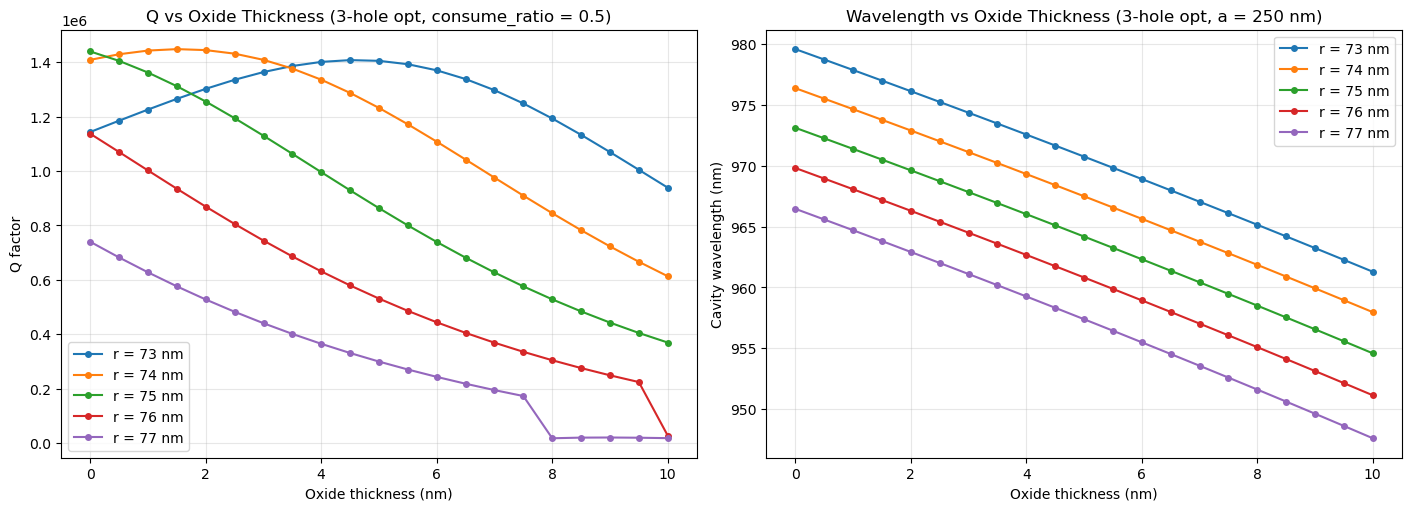

In [13]:
# ── Plot combined sweep results ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for r_nm in r_nm_list:
    ax1.plot(t_ox_vals, results[r_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')
    lambdas = [a_nm / f for f in results[r_nm]['freqs']]
    ax2.plot(t_ox_vals, lambdas, 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (3-hole opt, consume_ratio = 0.5)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (3-hole opt, a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Sweep: Q vs oxide thickness for different consume ratios

In [14]:
# Combined sweep: oxide thickness for each consume_ratio (standard r = 75 nm)
cr_list = np.linspace(0, 1.0, 6)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
t_ox_vals_cr = np.linspace(0, 10, 21)  # nm
results_cr = {}  # {cr: {'Qs': [...], 'freqs': [...]}}

options_sweep3 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for cr in cr_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- consume_ratio = {cr:.2f} ---')
    for t_ox_nm in t_ox_vals_cr:
        phc_s = cavity_oxidized_3h(t_ox_nm, consume_ratio=cr)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep3)

        # Q-based mode selection: find candidates near f_prev, pick highest Q
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_cr[cr] = {'Qs': Qs, 'freqs': freqs}

print('\nConsume ratio sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals_cr, 'cr_list': np.array(cr_list)}
    for cr in cr_list:
        arrays[f'Qs_cr{cr:.2f}'] = np.array(results_cr[cr]['Qs'])
        arrays[f'freqs_cr{cr:.2f}'] = np.array(results_cr[cr]['freqs'])
    save_sweep('3h_consume_ratio_oxide', arrays, r_nm=75, cr_list=cr_list.tolist())


--- consume_ratio = 0.00 ---
  t_ox =  0.00 nm,  Q =  1438926.2,  f = 0.25691  (mode 8)
  t_ox =  0.50 nm,  Q =  1452958.4,  f = 0.25677  (mode 8)
  t_ox =  1.00 nm,  Q =  1463522.6,  f = 0.25664  (mode 8)
  t_ox =  1.50 nm,  Q =  1470676.2,  f = 0.25651  (mode 8)
  t_ox =  2.00 nm,  Q =  1474522.6,  f = 0.25638  (mode 8)
  t_ox =  2.50 nm,  Q =  1475204.9,  f = 0.25625  (mode 8)
  t_ox =  3.00 nm,  Q =  1472899.7,  f = 0.25612  (mode 8)
  t_ox =  3.50 nm,  Q =  1467810.0,  f = 0.25600  (mode 8)
  t_ox =  4.00 nm,  Q =  1460157.8,  f = 0.25587  (mode 8)
  t_ox =  4.50 nm,  Q =  1450177.6,  f = 0.25575  (mode 8)
  t_ox =  5.00 nm,  Q =  1438109.7,  f = 0.25563  (mode 8)
  t_ox =  5.50 nm,  Q =  1424195.0,  f = 0.25551  (mode 8)
  t_ox =  6.00 nm,  Q =  1408669.7,  f = 0.25539  (mode 8)
  t_ox =  6.50 nm,  Q =  1391762.2,  f = 0.25527  (mode 8)
  t_ox =  7.00 nm,  Q =  1373689.1,  f = 0.25516  (mode 8)
  t_ox =  7.50 nm,  Q =  1354653.7,  f = 0.25504  (mode 8)
  t_ox =  8.00 nm,  Q =  1

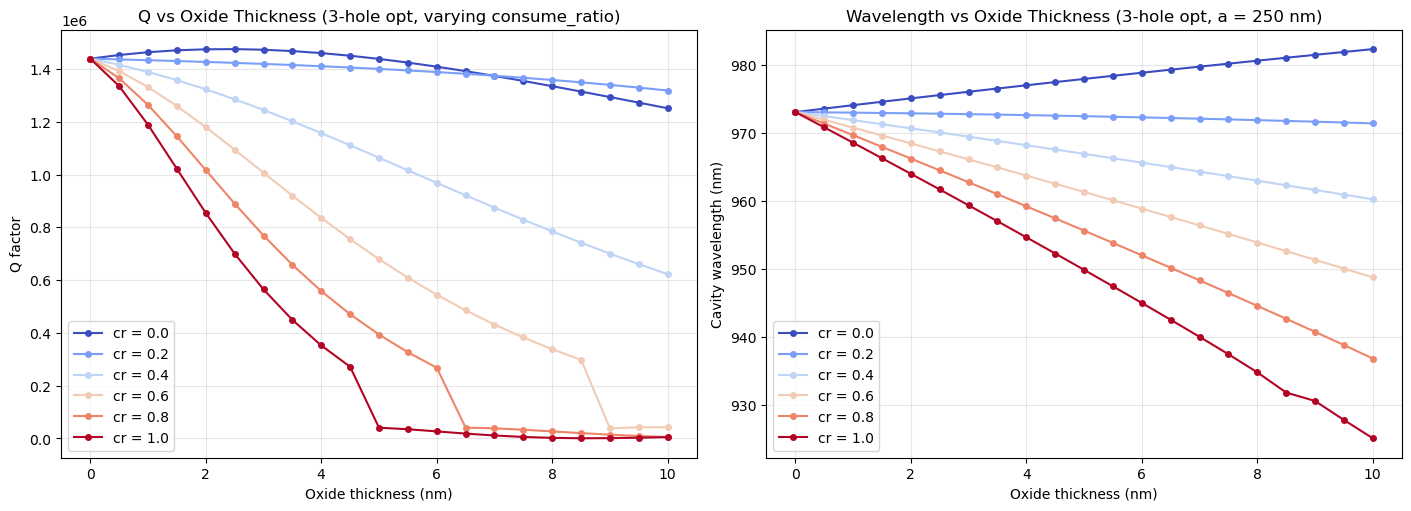

In [15]:
# ── Plot consume_ratio sweep results ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.coolwarm
colors = [cmap(i / (len(cr_list) - 1)) for i in range(len(cr_list))]

for i, cr in enumerate(cr_list):
    label = f'cr = {cr:.1f}'
    ax1.plot(t_ox_vals_cr, results_cr[cr]['Qs'], 'o-', ms=4, lw=1.5, label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_cr[cr]['freqs']]
    ax2.plot(t_ox_vals_cr, lambdas, 'o-', ms=4, lw=1.5, label=label, color=colors[i])

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (3-hole opt, varying consume_ratio)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (3-hole opt, a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Lattice constant sweep (no oxide, constant r/a and d/a)

In [10]:
# Sweep lattice constant (no oxide, r/a and d/a constant)
# Since r/a and d/a are fixed, the normalized simulation is invariant.
# Only the physical wavelength lambda = a / f_norm changes.
a_nm_list = np.linspace(220, 280, 13)  # nm
Qs_a = []
freqs_a = []
lambdas_a = []

options_a = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
             'gradients': 'approx', 'compute_im': False}

print(f'Lattice constant sweep (r/a = {ra:.4f}, d/a = {dslab:.4f}, no oxide):')
print(f'{"a (nm)":>8}  {"r (nm)":>8}  {"d (nm)":>8}  {"f (norm)":>10}  {"λ (nm)":>10}  {"Q":>12}')
print('-' * 70)

for a_val in a_nm_list:
    # Build unoxidized cavity — normalized structure is identical for all a_nm
    phc_a = cavity_oxidized_3h(0)
    gme_a = legume.GuidedModeExp(phc_a, gmax=gmax, truncate_g=truncate_g)
    gme_a.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_a)

    # Q-based mode selection
    all_freqs = gme_a.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_base) < 0.005)[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_a.compute_rad(0, [c])
        Qc = gme_a.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_norm = gme_a.freqs[0, mind]
    lam = a_val / f_norm

    Qs_a.append(best_Q)
    freqs_a.append(f_norm)
    lambdas_a.append(lam)
    print(f'{a_val:8.1f}  {ra*a_val:8.1f}  {dslab*a_val:8.1f}  {f_norm:10.5f}  {lam:10.1f}  {best_Q:12.1f}')

print('\nLattice constant sweep complete.')
print(f'Note: Q is constant ({Qs_a[0]:.0f}) because normalized geometry is invariant.')

if SAVE_DATA:
    save_sweep('lattice_constant', {
        'a_nm': np.array(a_nm_list),
        'Qs': np.array(Qs_a),
        'freqs': np.array(freqs_a),
        'lambdas_nm': np.array(lambdas_a),
    }, ra=ra, dslab=dslab, t_ox_nm=0, consume_ratio=0)

Lattice constant sweep (r/a = 0.3000, d/a = 0.6800, no oxide):
  a (nm)    r (nm)    d (nm)    f (norm)      λ (nm)             Q
----------------------------------------------------------------------
   220.0      66.0     149.6     0.25691       856.3     1438926.2
   225.0      67.5     153.0     0.25691       875.8     1438926.2
   230.0      69.0     156.4     0.25691       895.3     1438926.2
   235.0      70.5     159.8     0.25691       914.7     1438926.2
   240.0      72.0     163.2     0.25691       934.2     1438926.2
   245.0      73.5     166.6     0.25691       953.6     1438926.2
   250.0      75.0     170.0     0.25691       973.1     1438926.2
   255.0      76.5     173.4     0.25691       992.6     1438926.2
   260.0      78.0     176.8     0.25691      1012.0     1438926.2
   265.0      79.5     180.2     0.25691      1031.5     1438926.2
   270.0      81.0     183.6     0.25691      1051.0     1438926.2
   275.0      82.5     187.0     0.25691      1070.4     14389

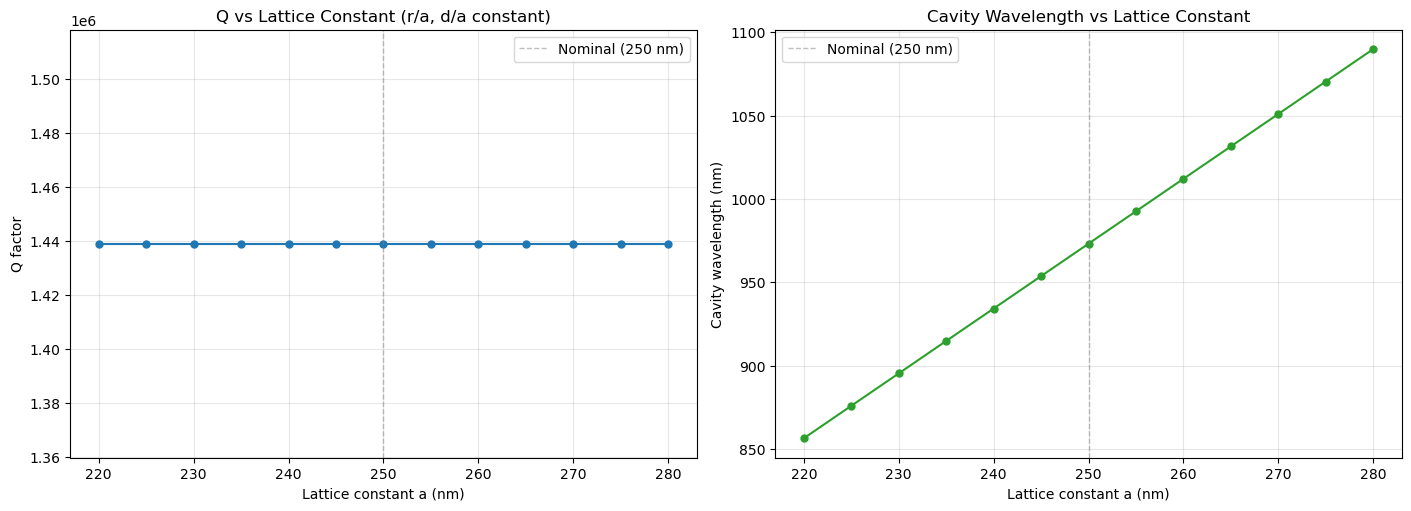

In [11]:
# ── Plot lattice constant sweep results ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax1.plot(a_nm_list, Qs_a, 'o-', lw=1.5, ms=5)
ax1.axvline(250, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (250 nm)')
ax1.set_xlabel('Lattice constant a (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Lattice Constant (r/a, d/a constant)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(a_nm_list, lambdas_a, 'o-', lw=1.5, ms=5, color='tab:green')
ax2.axvline(250, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (250 nm)')
ax2.set_xlabel('Lattice constant a (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title('Cavity Wavelength vs Lattice Constant')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Hole Shape Analysis (no oxide)

Study the effect of non-ideal hole shapes on Q factor:
1. **Conical taper** — sidewall angle from RIE etching
2. **Piecewise taper** — independent top/bottom sidewall angles (barrel, hourglass)
3. **Elliptical holes** — varying ellipticity and rotation angle

In [9]:
from legume import Ellipse

n_slices_shape = 24  # staircase sub-layers for taper studies

# ── Conical taper ──────────────────────────────────────────────────────────
def cavity_conical_3h(taper_angle_deg, n_slices=24, r_nm=None):
    """L3 cavity with conical (tapered) holes.
    r_top = ra, r_bottom = ra - dslab * tan(angle)."""
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    taper_rad = np.radians(taper_angle_deg)
    r_top = r_a
    r_bottom = r_a - dslab * np.tan(taper_rad)
    if r_bottom <= 0:
        raise ValueError(f'Taper too large: r_bottom = {r_bottom*a_nm:.1f} nm')

    d_slice = dslab / n_slices
    phc = legume.PhotCryst(lattice)

    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice
        frac = z_center / dslab
        r_k = r_top * (1 - frac) + r_bottom * frac
        phc.add_layer(d=d_slice, eps_b=n_slab**2)

        for ic in range(nc):
            yc = yp[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0
            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))
            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_k), layer=k)
    return phc


# ── Piecewise taper (barrel / hourglass) ──────────────────────────────────
def cavity_piecewise_3h(angle_top_deg, angle_bottom_deg, n_slices=24, r_nm=None):
    """L3 cavity with piecewise-linear tapered holes.
    Top half: r(z) = ra - z*tan(angle_top)
    Bottom half: r(z) = ra - (dslab-z)*tan(angle_bottom)"""
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    tan_top = np.tan(np.radians(angle_top_deg))
    tan_bot = np.tan(np.radians(angle_bottom_deg))
    d_slice = dslab / n_slices

    r_slices = []
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice
        if z_center <= dslab / 2:
            r_k = r_a - z_center * tan_top
        else:
            r_k = r_a - (dslab - z_center) * tan_bot
        r_slices.append(r_k)
    if min(r_slices) <= 0:
        raise ValueError(f'Radius goes to zero: min r = {min(r_slices)*a_nm:.1f} nm')

    phc = legume.PhotCryst(lattice)
    for k in range(n_slices):
        phc.add_layer(d=d_slice, eps_b=n_slab**2)
        for ic in range(nc):
            yc = yp[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0
            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))
            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_slices[k]), layer=k)
    return phc


# ── Elliptical holes ──────────────────────────────────────────────────────
def cavity_elliptical_3h(ellipticity, phi_deg=0, r_nm=None):
    """L3 cavity with elliptical holes (constant area).
    e = ry/rx.  rx = r/sqrt(e), ry = r*sqrt(e).  phi = rotation in degrees."""
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    rx = r_a / np.sqrt(ellipticity)
    ry = r_a * np.sqrt(ellipticity)
    phi = np.radians(phi_deg)

    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=dslab, eps_b=n_slab**2)
    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0
        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))
        for (px, py) in positions:
            phc.add_shape(Ellipse(x_cent=px, y_cent=py, rx=rx, ry=ry, phi=phi),
                          layer=0)
    return phc

print('Cavity builders defined: cavity_conical_3h, cavity_piecewise_3h, cavity_elliptical_3h')

Cavity builders defined: cavity_conical_3h, cavity_piecewise_3h, cavity_elliptical_3h


### Conical taper sweep

In [10]:
# Sweep taper angle 0-5 degrees
taper_angles = np.linspace(0, 5, 21)
Qs_taper = []
freqs_taper = []

options_taper = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base

print('Sweeping taper angle:')
for angle in taper_angles:
    phc_s = cavity_conical_3h(angle, n_slices=n_slices_shape)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_taper)

    all_freqs = gme_s.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > 0 and Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s
    Qs_taper.append(best_Q)
    freqs_taper.append(f_s)

    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  angle = {angle:5.2f} deg,  r_bot = {r_bot*a_nm:5.1f} nm,  '
          f'Q = {best_Q:10.1f},  f = {f_s:.5f}')

Qs_taper = np.array(Qs_taper)
freqs_taper = np.array(freqs_taper)
print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('3h_taper_angle', {
        'taper_angles': taper_angles,
        'Qs': Qs_taper,
        'freqs': freqs_taper,
    }, n_slices=n_slices_shape)

Sweeping taper angle:
  angle =  0.00 deg,  r_bot =  75.0 nm,  Q =  1438926.2,  f = 0.25691
  angle =  0.25 deg,  r_bot =  74.3 nm,  Q =  1441989.1,  f = 0.25659
  angle =  0.50 deg,  r_bot =  73.5 nm,  Q =  1346128.0,  f = 0.25628
  angle =  0.75 deg,  r_bot =  72.8 nm,  Q =  1186680.7,  f = 0.25598
  angle =  1.00 deg,  r_bot =  72.0 nm,  Q =  1005429.2,  f = 0.25569
  angle =  1.25 deg,  r_bot =  71.3 nm,  Q =   831806.5,  f = 0.25540
  angle =  1.50 deg,  r_bot =  70.5 nm,  Q =   679880.4,  f = 0.25512
  angle =  1.75 deg,  r_bot =  69.8 nm,  Q =   553252.4,  f = 0.25484
  angle =  2.00 deg,  r_bot =  69.1 nm,  Q =   450335.9,  f = 0.25457
  angle =  2.25 deg,  r_bot =  68.3 nm,  Q =   367673.7,  f = 0.25431
  angle =  2.50 deg,  r_bot =  67.6 nm,  Q =   301556.0,  f = 0.25405
  angle =  2.75 deg,  r_bot =  66.8 nm,  Q =   248661.5,  f = 0.25379
  angle =  3.00 deg,  r_bot =  66.1 nm,  Q =   206232.5,  f = 0.25354
  angle =  3.25 deg,  r_bot =  65.3 nm,  Q =   172060.5,  f = 0.2532

Loading from: data/2026-04-01_114658_3h_taper_angle


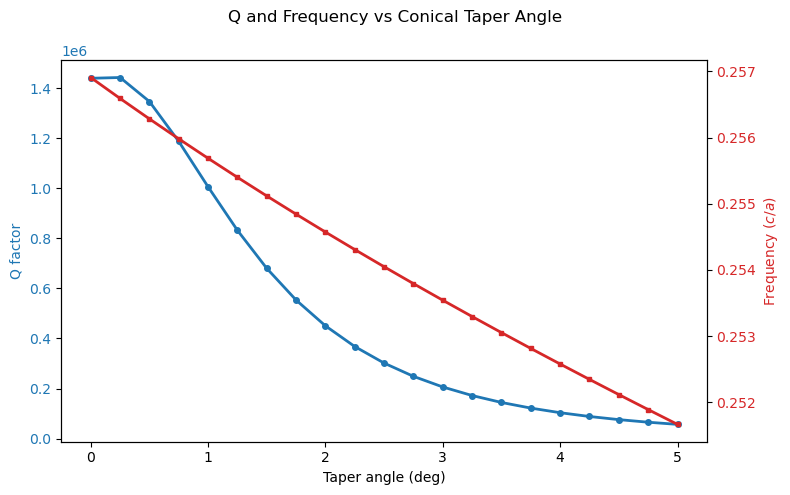

In [11]:
# ── Taper sweep plot ────────────────────────────────────────────────────
import glob, os

folders = sorted(glob.glob('data/*_3h_taper_angle'))
if not folders:
    raise FileNotFoundError('No 3h_taper_angle data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

taper_angles = np.load(os.path.join(folder, 'taper_angles.npy'))
Qs_taper     = np.load(os.path.join(folder, 'Qs.npy'))
freqs_taper  = np.load(os.path.join(folder, 'freqs.npy'))

fig, ax1 = plt.subplots(figsize=(8, 5))
color_q, color_f = '#1f77b4', '#d62728'

ax1.plot(taper_angles, Qs_taper, 'o-', color=color_q, lw=2, ms=4)
ax1.set_xlabel('Taper angle (deg)')
ax1.set_ylabel('Q factor', color=color_q)
ax1.tick_params(axis='y', labelcolor=color_q)

ax2 = ax1.twinx()
ax2.plot(taper_angles, freqs_taper, 's-', color=color_f, lw=2, ms=3)
ax2.set_ylabel('Frequency ($c/a$)', color=color_f)
ax2.tick_params(axis='y', labelcolor=color_f)

fig.suptitle('Q and Frequency vs Conical Taper Angle')
fig.tight_layout()
plt.show()

### Piecewise taper heatmap (barrel / hourglass)

Vary top and bottom sidewall angles independently.  
Positive angle = narrows towards slab centre. Negative = widens (barrel).

In [12]:
# 2D heatmap sweep: angle_top vs angle_bottom
angles_pw = np.linspace(-3, 5, 9)  # 1 deg steps, 45 runs
n_angles = len(angles_pw)

Q_matrix = np.full((n_angles, n_angles), np.nan)
f_matrix = np.full((n_angles, n_angles), np.nan)

options_pw = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
               'gradients': 'approx', 'compute_im': False}

total = n_angles * (n_angles + 1) // 2
count = 0

print(f'Piecewise-taper heatmap: {total} runs ({n_angles}x{n_angles}, lower triangle)')
for i, a_top in enumerate(angles_pw):
    f_prev = f_base
    for j, a_bot in enumerate(angles_pw):
        if j > i:
            continue
        count += 1
        try:
            phc_s = cavity_piecewise_3h(a_top, a_bot, n_slices=n_slices_shape)
        except ValueError as e:
            print(f'  [{count:3d}/{total}] top={a_top:+5.1f}, bot={a_bot:+5.1f} deg  SKIPPED ({e})')
            continue

        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_pw)

        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > 0 and Qc > best_Q:
                best_Q, mind = Qc, c

        if best_Q > 0:
            f_s = gme_s.freqs[0, mind]
            f_prev = f_s
            Q_matrix[i, j] = best_Q
            f_matrix[i, j] = f_s
            if i != j:
                Q_matrix[j, i] = best_Q
                f_matrix[j, i] = f_s

        print(f'  [{count:3d}/{total}] top={a_top:+5.1f}, bot={a_bot:+5.1f} deg  '
              f'Q={best_Q:10.1f}  f={gme_s.freqs[0, mind]:.5f}')

print('\nHeatmap sweep complete.')

if SAVE_DATA:
    save_sweep('3h_piecewise_taper_heatmap', {
        'angles': angles_pw,
        'Q_matrix': Q_matrix,
        'f_matrix': f_matrix,
    }, n_slices=n_slices_shape)

Piecewise-taper heatmap: 45 runs (9x9, lower triangle)
  [  1/45] top= -3.0, bot= -3.0 deg  Q=  645281.3  f=0.25898
  [  2/45] top= -2.0, bot= -3.0 deg  Q=  759735.1  f=0.25864
  [  3/45] top= -2.0, bot= -2.0 deg  Q=  931807.7  f=0.25826
  [  4/45] top= -1.0, bot= -3.0 deg  Q=  820589.7  f=0.25833
  [  5/45] top= -1.0, bot= -2.0 deg  Q= 1045465.7  f=0.25793
  [  6/45] top= -1.0, bot= -1.0 deg  Q= 1227627.5  f=0.25757
  [  7/45] top= +0.0, bot= -3.0 deg  Q=  813265.4  f=0.25806
  [  8/45] top= +0.0, bot= -2.0 deg  Q= 1060885.1  f=0.25764
  [  9/45] top= +0.0, bot= -1.0 deg  Q= 1296574.5  f=0.25725
  [ 10/45] top= +0.0, bot= +0.0 deg  Q= 1438926.2  f=0.25691
  [ 11/45] top= +1.0, bot= -3.0 deg  Q=  750620.9  f=0.25783
  [ 12/45] top= +1.0, bot= -2.0 deg  Q=  983305.9  f=0.25738
  [ 13/45] top= +1.0, bot= -1.0 deg  Q= 1229033.0  f=0.25697
  [ 14/45] top= +1.0, bot= +0.0 deg  Q= 1424976.2  f=0.25660
  [ 15/45] top= +1.0, bot= +1.0 deg  Q= 1492838.9  f=0.25627
  [ 16/45] top= +2.0, bot= -3.

Loading from: data/2026-04-01_121843_3h_piecewise_taper_heatmap


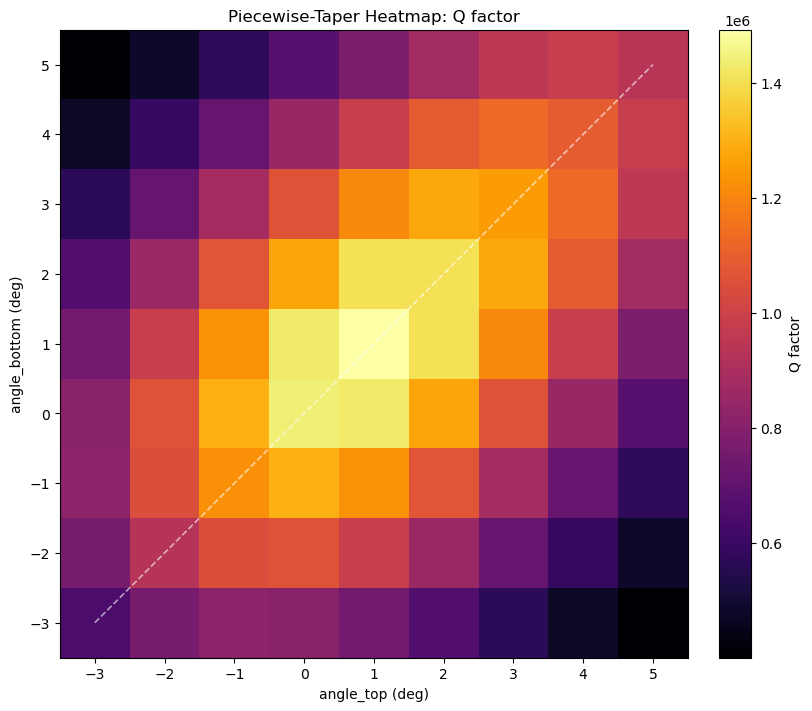

In [13]:
# ── Piecewise-taper heatmap plot ──────────────────────────────────────────
import glob, os
from matplotlib.colors import LogNorm

folders = sorted(glob.glob('data/*_3h_piecewise_taper_heatmap'))
if not folders:
    raise FileNotFoundError('No 3h_piecewise_taper_heatmap data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

angles_pw = np.load(os.path.join(folder, 'angles.npy'))
Q_matrix  = np.load(os.path.join(folder, 'Q_matrix.npy'))

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

da = angles_pw[1] - angles_pw[0]
edges = np.append(angles_pw - da/2, angles_pw[-1] + da/2)

Q_valid = Q_matrix[Q_matrix > 0]
use_log = (Q_valid.max() / Q_valid.min() > 100) if len(Q_valid) > 0 else False
norm = LogNorm(vmin=Q_valid.min(), vmax=Q_valid.max()) if use_log else None

pcm = ax.pcolormesh(edges, edges, Q_matrix, cmap='inferno', shading='flat', norm=norm)
fig.colorbar(pcm, ax=ax, label='Q factor')

ax.plot([angles_pw[0], angles_pw[-1]], [angles_pw[0], angles_pw[-1]],
        'w--', lw=1.2, alpha=0.6)

ax.set_xlabel('angle_top (deg)')
ax.set_ylabel('angle_bottom (deg)')
ax.set_title('Piecewise-Taper Heatmap: Q factor')
ax.set_aspect('equal')
plt.show()

### Elliptical holes

Replace circular holes with ellipses of the same area ($r_x r_y = r^2$).  
Ellipticity $e = r_y/r_x$: $e=1$ circular, $e>1$ elongated along $y$ ($\Gamma$-M), $e<1$ along $x$ (cavity axis).  
Rotation angle $\phi$: rotates each ellipse CCW. Equivalence: $(e,\,\phi) \equiv (1/e,\,\phi+90°)$.

In [ ]:
# Sweep ellipticity (constant hole area) — outward from e=1.0
ellipticities = np.linspace(0.6, 1.6, 21)
i_base = np.argmin(np.abs(ellipticities - 1.0))  # start here

Qs_ellip = np.full(len(ellipticities), np.nan)
freqs_ellip = np.full(len(ellipticities), np.nan)

options_ellip = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

def _run_ellip(idx, f_prev_val):
    e = ellipticities[idx]
    phc_e = cavity_elliptical_3h(e)
    gme_e = legume.GuidedModeExp(phc_e, gmax=gmax, truncate_g=truncate_g)
    gme_e.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_ellip)

    all_freqs = gme_e.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    if len(candidates) == 0:
        print(f'  e = {e:5.2f}  NO MODE IN BANDGAP')
        return f_prev_val

    freq_dists = np.abs(all_freqs[candidates] - f_prev_val)
    mind = candidates[np.argmin(freq_dists)]
    (fim, _, _) = gme_e.compute_rad(0, [mind])
    best_Q = gme_e.freqs[0, mind] / (2 * fim[0])
    f_e = gme_e.freqs[0, mind]

    Qs_ellip[idx] = best_Q
    freqs_ellip[idx] = f_e

    rxe = ra / np.sqrt(e)
    rye = ra * np.sqrt(e)
    print(f'  e = {e:5.2f}  rx = {rxe*a_nm:5.1f} nm  ry = {rye*a_nm:5.1f} nm  '
          f'Q = {best_Q:10.1f}  f = {f_e:.5f}')
    return f_e

# Forward sweep: e=1.0 → 1.6
print('Sweeping ellipticity (outward from e=1.0):')
print('--- Forward (e=1.0 -> 1.6) ---')
f_prev = f_base
for idx in range(i_base, len(ellipticities)):
    f_prev = _run_ellip(idx, f_prev)

# Backward sweep: e<1.0 → 0.6
print('--- Backward (e=1.0 -> 0.6) ---')
f_prev = f_base
for idx in range(i_base - 1, -1, -1):
    f_prev = _run_ellip(idx, f_prev)

print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('3h_ellipticity', {
        'ellipticities': ellipticities,
        'Qs': Qs_ellip,
        'freqs': freqs_ellip,
    }, r_nm=ra*a_nm)

Loading from: data/2026-04-01_122409_3h_ellipticity


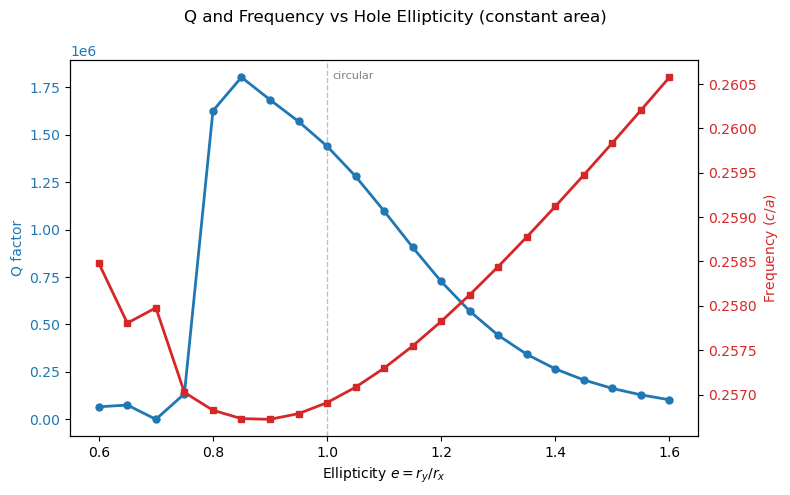

In [15]:
# ── Ellipticity sweep plot ────────────────────────────────────────────────
import glob, os

folders = sorted(glob.glob('data/*_3h_ellipticity'))
if not folders:
    raise FileNotFoundError('No 3h_ellipticity data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

ellipticities = np.load(os.path.join(folder, 'ellipticities.npy'))
Qs_ellip      = np.load(os.path.join(folder, 'Qs.npy'))
freqs_ellip   = np.load(os.path.join(folder, 'freqs.npy'))

fig, ax1 = plt.subplots(figsize=(8, 5))
color_q, color_f = '#1f77b4', '#d62728'

ax1.plot(ellipticities, Qs_ellip, 'o-', color=color_q, lw=2, ms=5)
ax1.set_xlabel('Ellipticity $e = r_y / r_x$')
ax1.set_ylabel('Q factor', color=color_q)
ax1.tick_params(axis='y', labelcolor=color_q)
ax1.axvline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
ax1.text(1.01, ax1.get_ylim()[1]*0.97, 'circular', fontsize=8, color='gray', va='top')

ax2 = ax1.twinx()
ax2.plot(ellipticities, freqs_ellip, 's-', color=color_f, lw=2, ms=4)
ax2.set_ylabel('Frequency ($c/a$)', color=color_f)
ax2.tick_params(axis='y', labelcolor=color_f)

fig.suptitle('Q and Frequency vs Hole Ellipticity (constant area)')
fig.tight_layout()
plt.show()

### Ellipticity × rotation angle

In [ ]:
# 2D sweep: ellipticity vs rotation angle — ellipticity swept outward from 1.0
ellipticities_2d = np.linspace(0.7, 1.4, 8)
phi_degs = np.linspace(0, 90, 10)
n_e = len(ellipticities_2d)
n_phi = len(phi_degs)
i_base_2d = np.argmin(np.abs(ellipticities_2d - 1.0))

Q_map = np.full((n_e, n_phi), np.nan)
f_map = np.full((n_e, n_phi), np.nan)

options_er = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
               'gradients': 'approx', 'compute_im': False}

def _run_er(i_e, f_seed):
    e = ellipticities_2d[i_e]
    f_prev = f_seed
    for i_phi, phi in enumerate(phi_degs):
        phc_er = cavity_elliptical_3h(e, phi_deg=phi)
        gme_er = legume.GuidedModeExp(phc_er, gmax=gmax, truncate_g=truncate_g)
        gme_er.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_er)

        all_freqs = gme_er.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        if len(candidates) == 0:
            print(f'  e={e:5.2f}  phi={phi:5.1f} deg  NO MODE')
            continue

        freq_dists = np.abs(all_freqs[candidates] - f_prev)
        mind = candidates[np.argmin(freq_dists)]
        (fim, _, _) = gme_er.compute_rad(0, [mind])
        best_Q = gme_er.freqs[0, mind] / (2 * fim[0])

        if best_Q > 0:
            f_er = gme_er.freqs[0, mind]
            f_prev = f_er
            Q_map[i_e, i_phi] = best_Q
            f_map[i_e, i_phi] = f_er

        print(f'  e={e:5.2f}  phi={phi:5.1f} deg  '
              f'Q={best_Q:10.1f}  f={gme_er.freqs[0, mind]:.5f}')
    # Return phi=0 frequency as seed for next ellipticity step
    return f_map[i_e, 0] if not np.isnan(f_map[i_e, 0]) else f_seed

total = n_e * n_phi
print(f'Ellipticity x rotation sweep: {total} runs ({n_e} x {n_phi}), outward from e=1.0')

# Forward: e near 1.0 -> 1.4
print('--- Forward ---')
f_seed = f_base
for i_e in range(i_base_2d, n_e):
    f_seed = _run_er(i_e, f_seed)

# Backward: e near 1.0 -> 0.7
print('--- Backward ---')
f_seed = f_base
for i_e in range(i_base_2d - 1, -1, -1):
    f_seed = _run_er(i_e, f_seed)

print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('3h_ellipticity_rotation', {
        'ellipticities': ellipticities_2d,
        'phi_degs': phi_degs,
        'Q_map': Q_map,
        'f_map': f_map,
    }, r_nm=ra*a_nm)

Loading from: data/2026-04-01_124108_3h_ellipticity_rotation


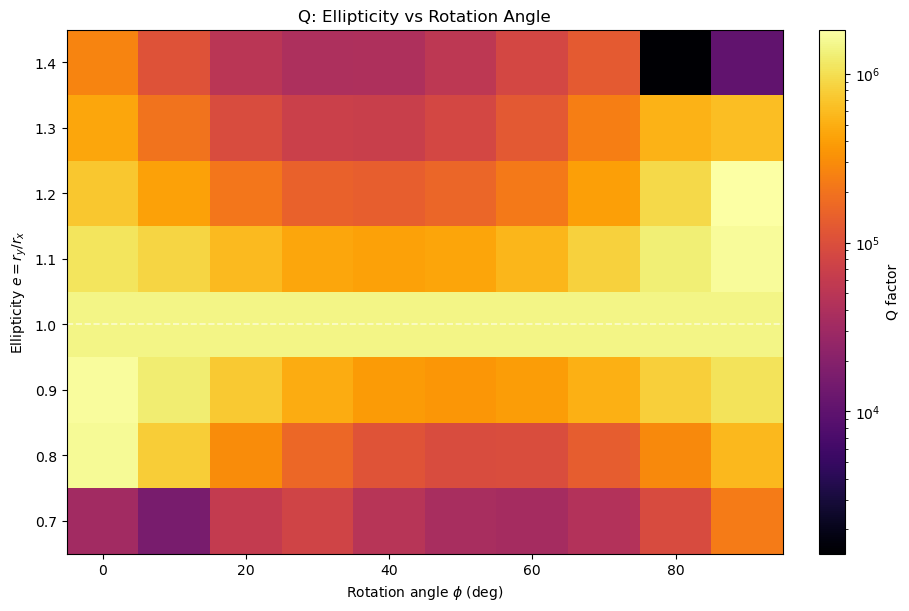

In [17]:
# ── Ellipticity x rotation heatmap plot ─────────────────────────────────
import glob, os
from matplotlib.colors import LogNorm

folders = sorted(glob.glob('data/*_3h_ellipticity_rotation'))
if not folders:
    raise FileNotFoundError('No 3h_ellipticity_rotation data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

ellipticities_2d = np.load(os.path.join(folder, 'ellipticities.npy'))
phi_degs         = np.load(os.path.join(folder, 'phi_degs.npy'))
Q_map            = np.load(os.path.join(folder, 'Q_map.npy'))

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

de = ellipticities_2d[1] - ellipticities_2d[0]
dp = phi_degs[1] - phi_degs[0]
e_edges = np.append(ellipticities_2d - de/2, ellipticities_2d[-1] + de/2)
p_edges = np.append(phi_degs - dp/2, phi_degs[-1] + dp/2)

Q_valid = Q_map[Q_map > 0]
use_log = (Q_valid.max() / Q_valid.min() > 100) if len(Q_valid) > 0 else False
norm = LogNorm(vmin=Q_valid.min(), vmax=Q_valid.max()) if use_log else None

pcm = ax.pcolormesh(p_edges, e_edges, Q_map, cmap='inferno', shading='flat', norm=norm)
fig.colorbar(pcm, ax=ax, label='Q factor')

ax.axhline(1.0, color='white', ls='--', lw=1.2, alpha=0.6)

ax.set_xlabel('Rotation angle $\\phi$ (deg)')
ax.set_ylabel('Ellipticity $e = r_y / r_x$')
ax.set_title('Q: Ellipticity vs Rotation Angle')
plt.show()